### Data loading, package installation

In [345]:
# load the processed_data_with_predicted_bias.csv file
data <- read.csv("data/processed_data.csv")

# install and load dplyr and purrr packages if not installed
if (!require(dplyr)) install.packages("dplyr")
if (!require(purrr)) install.packages("purrr")
if (!require(readr)) install.packages("readr")
if (!require(zoo)) install.packages("zoo")
if (!require(lubridate)) install.packages("lubridate")
if (!require(xgboost)) install.packages("xgboost")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(yardstick)) install.packages("yardstick")
if (!require(WVPlots)) install.packages("WVPlots")
if (!require(pROC)) install.packages("pROC")
if (!require(caret)) install.packages("caret")
if (!require(tidyr)) install.packages("tidyr")
if (!require(tidytext)) install.packages("tidytext")
library(dplyr)
library(purrr)
library(readr)
library(zoo)
library(lubridate)
library(xgboost)
library(ggplot2)
library(yardstick)
library(WVPlots)
library(pROC)
library(caret)
library(tidyr)
library(tidytext)


### How many speakers in each tournament (307 - 320)?

In [346]:
# count number of lines for each "tournament_id"
print(table(data$tournament_id))


307 308 309 310 311 312 313 314 315 316 317 318 319 320 
 72 228  72 660 108  72 384 144  48  60 354 714 120 264 


### Performance validation plan
Training data 307-316 –> Testing 317

Training data 307-317 –> Testing 318

Training data 307-318 –> Testing 319

Training data 307-319 –> Testing 320

In [348]:
# Final Data Prep: Factors are required for categorical support
categorical_cols <- c(
  "speaker_name",
  "is_male",
  "aff_side",
  "speaker_position_1",
  "speaker_position_2"
)
data <- data %>%
  mutate(across(all_of(categorical_cols), ~ as.integer(as.factor(.))))

# Feature Selection
base_features <- c("speaker_name", "is_male", "aff_side", "speaker_position_1", 
                   "speaker_position_2", "rolling_avg_5", "avg_teammate_rolling_score", 
                   "avg_opponent_rolling_score", "cumulative_debates", "years_debating")
motion_categories <- names(data)[16:35] 
features <- c(base_features, motion_categories)

# Target
target <- "speaker_points"
test_ids <- c(317, 318, 319, 320)
validation_results <- list()

# Validation Loop
for (tid in test_ids) {
  train_df <- data %>% filter(tournament_id >= 307 & tournament_id < tid)
  test_df  <- data %>% filter(tournament_id == tid)
  
  # Using the data frame directly allows XGBoost to handle the categorical names.
  dtrain <- xgb.DMatrix(data = train_df[, features], label = train_df[[target]])
  dtest  <- xgb.DMatrix(data = test_df[, features], label = test_df[[target]])
  
  # Training with categorical support
  model <- suppressWarnings(xgb.train(
    params = list(
      objective = "reg:squarederror",
      eval_metric = "rmse",
      tree_method = "hist",
      enable_categorical = TRUE,
      max_depth = 6,
      min_child_weight = 5,
      gamma = 1,
      subsample = 0.8,
      colsample_bytree = 0.8,
      eta = 0.05,
      lambda = 1,
      alpha = 0.5
    ),
    data = dtrain,
    nrounds = 100000,
    early_stopping_rounds = 30,
    watchlist = list(train = dtrain, test = dtest),
    verbose = 0
  ))
  
  # Predict
  preds <- predict(model, dtest)
  
  # Store results
  test_output <- test_df %>%
    select(tournament_id, debate_id, speaker_name, ballots_gained, actual = !!sym(target)) %>%
    mutate(predicted = preds)
  
  rmse <- sqrt(mean((test_output$actual - test_output$predicted)^2))
  validation_results[[as.character(tid)]] <- list(rmse = rmse, data = test_output)
  
  cat("Tournament", tid, "validation completed. RMSE:", round(rmse, 4), "\n")
}

Tournament 317 validation completed. RMSE: 3.6592 
Tournament 318 validation completed. RMSE: 4.4851 
Tournament 319 validation completed. RMSE: 3.0655 
Tournament 320 validation completed. RMSE: 3.4671 


### Evaluation

In [349]:
# Combine the list into one dataframe
final_predictions <- bind_rows(lapply(validation_results, function(x) x$data))

# Add an error column to see accuracy per speaker
final_predictions <- final_predictions %>%
  mutate(residual = actual - predicted,
         abs_error = abs(residual))

# Show final_predictions
head(final_predictions)

,tournament_id,debate_id,speaker_name,ballots_gained,actual,predicted,residual,abs_error
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,317,11099,244,3,78,80.86043,-2.8604279,2.8604279
2,317,11099,62,3,79,81.25014,-2.2501450,2.2501450
3,317,11099,371,3,74,75.37493,-1.3749313,1.3749313
4,317,11099,25,0,69,74.31234,-5.3123398,5.3123398
5,317,11099,182,0,70,73.34163,-3.3416290,3.3416290
6,317,11099,17,0,73,72.09578,0.9042206,0.9042206


### Variable importance

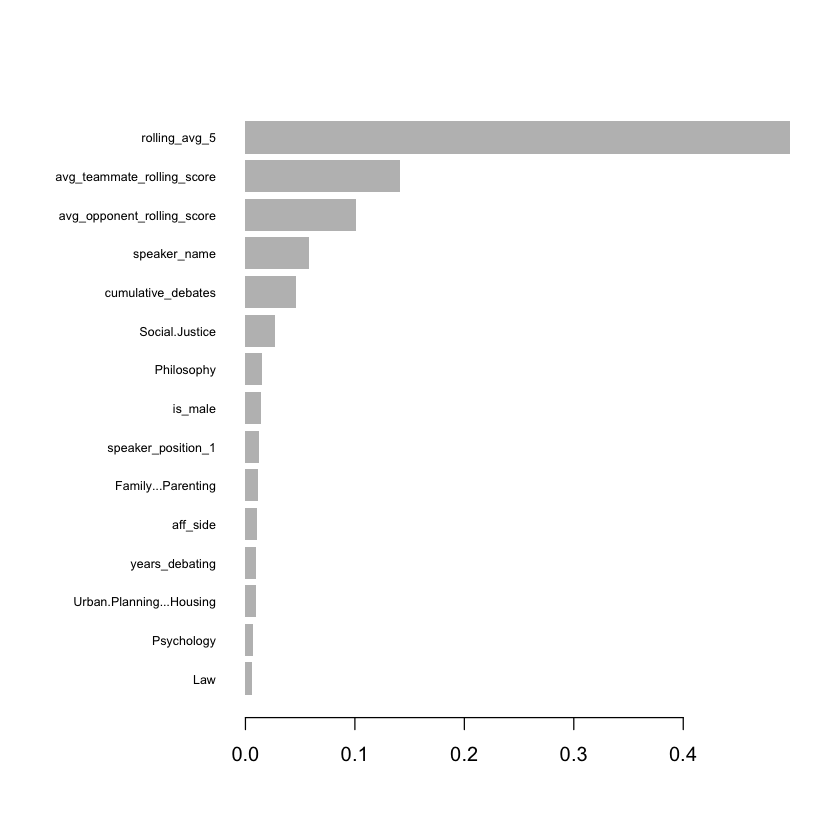

In [350]:
# Get importance from the very last model trained (Tournament 320)
importance_matrix <- xgb.importance(model = model)

# Plot the top 15 features
xgb.plot.importance(importance_matrix[1:15,])

### RMSE, MAE, R-squared

In [351]:
# Extract and combine all test predictions
all_preds_df <- map_df(validation_results, ~ .x$data)

# Function to calculate metrics
calculate_metrics <- function(actual, predicted) {
  mse <- mean((actual - predicted)^2)
  rmse <- sqrt(mse)
  mae <- mean(abs(actual - predicted))
  
  # R-squared: Proportion of variance explained
  rss <- sum((actual - predicted)^2)
  tss <- sum((actual - mean(actual))^2)
  r_squared <- 1 - (rss / tss)
  
  return(data.frame(SD_actual = sd(actual), RMSE = rmse, MAE = mae, R_squared = r_squared))
}

# Calculate overall metrics
overall_metrics <- calculate_metrics(all_preds_df$actual, all_preds_df$predicted)

# Calculate per-tournament metrics to check consistency
tournament_metrics <- all_preds_df %>%
  group_by(tournament_id) %>%
  summarise(
    SD_actual = sd(actual),
    RMSE = sqrt(mean((actual - predicted)^2)),
    MAE = mean(abs(actual - predicted)),
    R_squared = 1 - (sum((actual - predicted)^2) / sum((actual - mean(actual))^2))
  )

cat("\n--- OVERALL MODEL PERFORMANCE ---\n")
print(overall_metrics)
cat("\n--- TOURNAMENT CONSISTENCY ---\n")
print(tournament_metrics)


--- OVERALL MODEL PERFORMANCE ---
  SD_actual     RMSE      MAE R_squared
1  4.911454 4.014763 3.128818   0.33135

--- TOURNAMENT CONSISTENCY ---
# A tibble: 4 × 5
  tournament_id SD_actual  RMSE   MAE R_squared
          <int>     <dbl> <dbl> <dbl>     <dbl>
1           317      4.46  3.66  2.91     0.325
2           318      5.19  4.49  3.56     0.253
3           319      4.57  3.07  2.32     0.547
4           320      4.56  3.47  2.63     0.421


### Gain Curve Plot

Relative Gini score is the most important parameter here
= 0.59

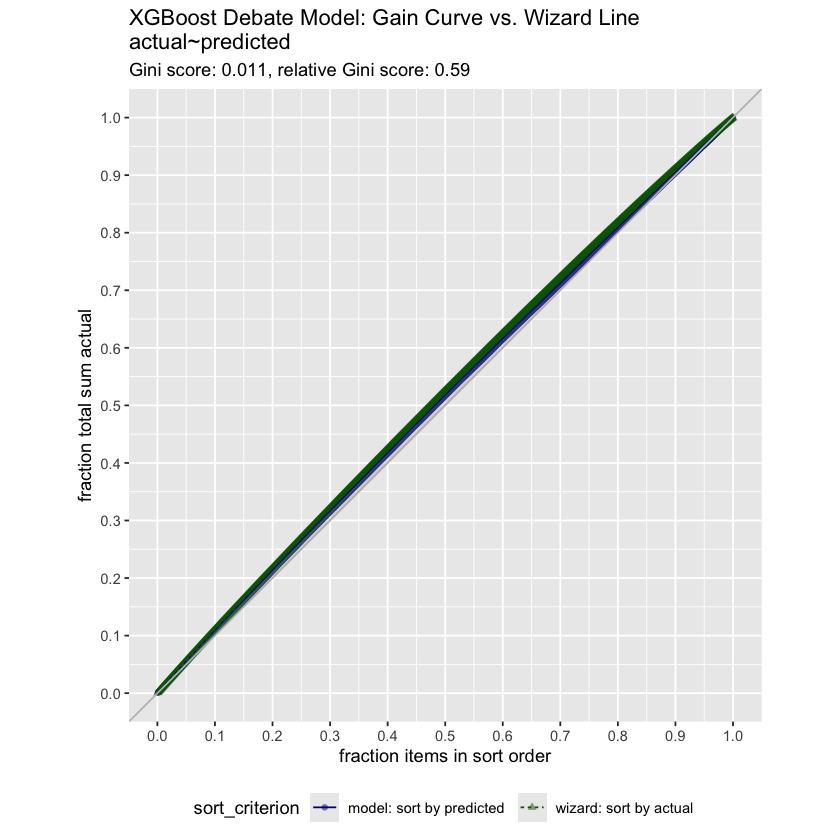

In [352]:
# Plot Gain Curve
GainCurvePlot(
  frame = final_predictions, 
  xvar = "predicted", 
  truthVar = "actual", 
  title = "XGBoost Debate Model: Gain Curve vs. Wizard Line"
)

cat("Relative Gini score is the most important parameter here\n")
cat("= 0.59")

<br>
<br>
<br>
<br>
<br>
<br>

### WINNING TEAM PREDICTION
### Evaluating the model based on its quality compared to ballotts_gained (the result of the entire team)

We sum up the predicted speaker_points and we will award the win to the team with the higher number. Then we compare with ballot_gained (actual win)

In [353]:
head(final_predictions)

,tournament_id,debate_id,speaker_name,ballots_gained,actual,predicted,residual,abs_error
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,317,11099,244,3,78,80.86043,-2.8604279,2.8604279
2,317,11099,62,3,79,81.25014,-2.2501450,2.2501450
3,317,11099,371,3,74,75.37493,-1.3749313,1.3749313
4,317,11099,25,0,69,74.31234,-5.3123398,5.3123398
5,317,11099,182,0,70,73.34163,-3.3416290,3.3416290
6,317,11099,17,0,73,72.09578,0.9042206,0.9042206


In [354]:
# Aggregate at the team level without breaking the structure
team_results <- final_predictions %>%
  group_by(debate_id) %>%
  # Create team ID (1 for the first 1-3 speakers, 2 for the next 4-6 speakers)
  mutate(team_id = rep(1:2, each = 3)) %>% 
  group_by(debate_id, team_id) %>%
  summarise(
    # Take the actual team result (ballots)
    team_score_raw = first(ballots_gained),
    # Sum the individual speaker predictions
    team_score_pred_raw = sum(predicted, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  # Comparison within the debate (who won?)
  group_by(debate_id) %>%
  mutate(
    # 1 for the team with more ballots, 0 for the others
    team_score = as.integer(team_score_raw == max(team_score_raw)),
    # 1 for the team with higher predicted points, 0 for the others
    team_score_predicted = as.integer(team_score_pred_raw == max(team_score_pred_raw))
  ) %>%
  ungroup()

# Convert to a single row (Affirmative team = team_id 1)
final_debate_summary <- team_results %>%
  # Keep only the first team from each debate
  filter(team_id == 1) %>%
  select(debate_id, aff_team_win = team_score, aff_team_win_pred = team_score_predicted)

head(final_debate_summary)


debate_id,aff_team_win,aff_team_win_pred
<int>,<int>,<int>
11099,1,1
11100,0,0
11101,0,0
11102,0,0
11103,1,1
11104,1,1


--- CONFUSION MATRIX --- 
          Reference
Prediction   0   1
         0  77  35
         1  29 101

--- MODEL STATISTICS --- 
Accuracy:                   0.7355 
Sensitivity (Win Recall):   0.7426 
Specificity (Loss Recall):  0.7264 
Precision:                  0.7769 
F1 Score:                   0.7594 


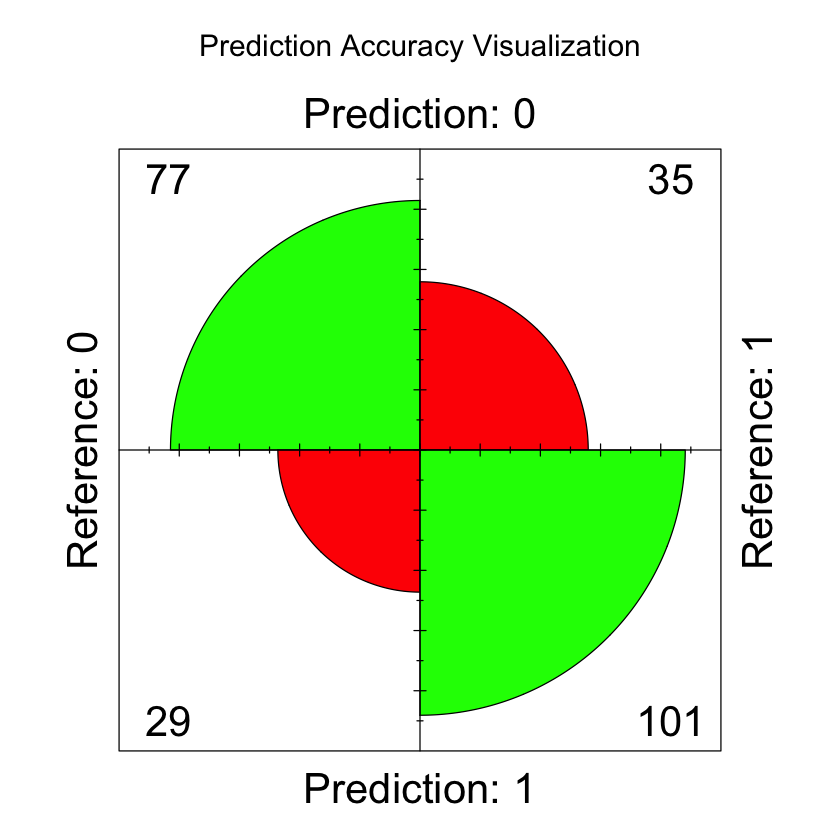

In [355]:
# Data preparation (convert to factors with identical levels 0 and 1)
actuals_f <- factor(as.character(final_debate_summary$aff_team_win), levels = c("0", "1"))
preds_f   <- factor(as.character(final_debate_summary$aff_team_win_pred), levels = c("0", "1"))

# Create Confusion Matrix
cm <- confusionMatrix(preds_f, actuals_f, positive = "1")
cat("--- CONFUSION MATRIX --- \n")
print(cm$table)

cat("\n--- MODEL STATISTICS --- \n")
cat("Accuracy:                  ", round(cm$overall['Accuracy'], 4), "\n")
cat("Sensitivity (Win Recall):  ", round(cm$byClass['Sensitivity'], 4), "\n")
cat("Specificity (Loss Recall): ", round(cm$byClass['Specificity'], 4), "\n")
cat("Precision:                 ", round(cm$byClass['Pos Pred Value'], 4), "\n")
cat("F1 Score:                  ", round(cm$byClass['F1'], 4), "\n")

# Visual fourfold plot
fourfoldplot(cm$table, color = c("#ff0000", "#00ff00"),
             conf.level = 0, margin = 1, main = "Prediction Accuracy Visualization")
